# Writing a vocabulary I: a family of kernels

Declare a kernel's shape once; write every model in the family as a
one-line function body.

**Time:** ~5 min &middot; **Runs on:** CPU (same code on GPU) &middot;
**You need:** [hawk basics](../tutorials)

A **vocabulary** is the named per-sample arrays and parameters a whole
family of kernels shares — every orbit model in a propagator needs a
position, a velocity, a timestep and gravity, say. Declare that shape
once as a `Kind`, and every model in the family becomes a plain function
body decorated with it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


## Declaring the shape

`slug="orbit"` names this `Kind` for build artifacts and diagnostics —
every kernel built from it shows up tagged `orbit`. `guard = DATA_ONLY`
runs every sample unconditionally; no stopping rule yet, that is a later
tutorial's `terminated` mask.

In [2]:
import hawk
from hawk import Mutable, Param, Vector
from hawk.ext import DATA_ONLY, KernelKind


class Orbit(KernelKind, slug="orbit"):
    r: Vector[3]
    v: Vector[3]
    dt: Param
    g: Param
    guard = DATA_ONLY


Orbit

__main__.Orbit

A model built on `Orbit` is a plain function, decorated `@Orbit`, that
reads `r, v, dt, g` without redeclaring any of them:

In [3]:
import numpy as np
from hawk.math import vec


@Orbit
def free_fall(r, v, dt, g, r_next: Mutable[Vector[3]], v_next: Mutable[Vector[3]]):
    v_new = v + dt * vec(0.0, 0.0, -g)
    v_next = v_new
    r_next = r + dt * v_new


free_fall


<Kernel free_fall slots=6>

`hawk.artifact.build` + `hawk.load`/`hawk.run` build and run it on the host:


In [4]:
import pathlib, tempfile

import hawk.artifact

work_dir = pathlib.Path(tempfile.mkdtemp())
n = 200
r0 = np.zeros((3, n)); r0[2] = 2.0
rng = np.random.default_rng(0)
v0 = np.zeros((3, n)); v0[0] = rng.uniform(1.0, 4.0, n)
r_next, v_next = np.zeros((3, n)), np.zeros((3, n))
hawk.artifact.build(free_fall, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "free_fall"), r=r0, v=v0, dt=0.2, g=9.81,
       r_next=r_next, v_next=v_next)
print("free_fall, x after one step (first 3 samples):", r_next[0, :3])


free_fall, x after one step (first 3 samples): [0.58217701 0.36187203 0.22458411]


A second model can add its own extra parameter on top of the shared
shape — `tethered` below adds a spring constant `k`:

In [5]:
@Orbit
def tethered(r, v, dt, g, k: Param,
             r_next: Mutable[Vector[3]], v_next: Mutable[Vector[3]]):
    a = vec(0.0, 0.0, -g) - k * r              # a spring pulling back to the origin
    v_new = v + dt * a
    v_next = v_new
    r_next = r + dt * v_new


hawk.artifact.build(tethered, work_dir, targets=("host",));


Both kernels built from the same `Kind`; `tethered`'s `k` is declared
only for that one model. Run a batch of each for one step and plot
where they land.

In [6]:
def run(kernel_name, **extra):
    r_next, v_next = np.zeros((3, n)), np.zeros((3, n))
    kernel_host = hawk.load(work_dir, kernel_name)
    hawk.run(kernel_host, r=r0, v=v0, dt=0.2, g=9.81,
           r_next=r_next, v_next=v_next, **extra)
    return r_next


falling = run("free_fall")
tethered_r = run("tethered", k=2.0)   # k: one broadcast value, not per-sample


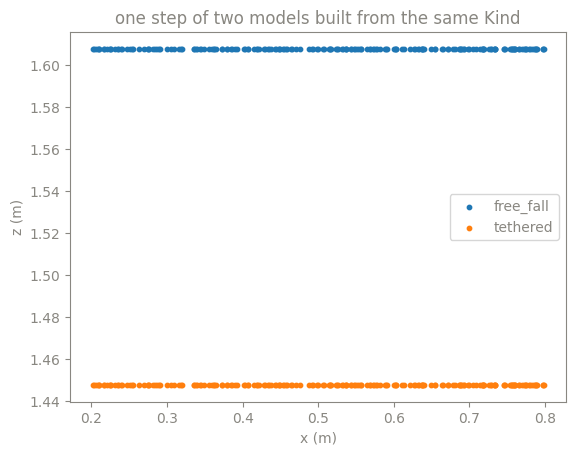

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(falling[0], falling[2], s=10, label="free_fall")
ax.scatter(tethered_r[0], tethered_r[2], s=10, label="tethered")
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("one step of two models built from the same Kind")
ax.legend()
plt.show()

## The one-line spelling

`class Orbit(KernelKind, ...)` is sugar over one `Kind(...)` call — the
same object either way, so every downstream consumer sees the identical
`Kind`:

In [8]:
from hawk.ext import Kind

Orbit_oneline = Kind("orbit",
                      vocabulary=dict(r=Vector[3], v=Vector[3], dt=Param, g=Param),
                      guard=DATA_ONLY)
Orbit_oneline == Orbit.kind

True

## What just happened

- `Orbit` declared ONE shared shape (`r, v, dt, g`); `free_fall` and
  `tethered` are plain function bodies, each decorated `@Orbit`.
- Every kernel can still add its own parameters too — `tethered`'s `k` is
  not shared, only declared for that one model.
- `guard = DATA_ONLY` runs every sample unconditionally; a later
  tutorial's `terminated` mask is what lets a kernel stop on its own.

## Try this

Add a third `@Orbit` model, `drift`, with no acceleration at all
(`v_next = v; r_next = r + dt * v`) — no new vocabulary, just another
function body.

## Next

[Extend it by inheritance](02_extend_by_inheritance) — add a drag
coefficient to `Orbit` without touching it. Deeper: every kind field
(output, sink, guard) in the
[`hawk.ext` API reference](../api/generated/hawk.ext).